In [1]:
import sys
sys.path.append('../shared')
from config_loader import load_config
from offset_calculator import OffsetCalculator
from offset_diagnostics import OffsetDiagnostics

config = load_config('../config.json')
calc = OffsetCalculator(config)
diag = OffsetDiagnostics()

In [2]:
calc.load_data()
calc.merge_bsst()
diag.check_missing_values(calc.df)

Records deleted (dml_year_imps = -999): 2,509 (0.01%)
Total records: 27,052,200
Feature                          Zeros         Null
ODOMETER                    10,308,462            0
CALC_VEH_AGE                         0            0
STATE                                0            0
BSST                                 0       17,469


In [3]:
calc.apply_odometer_defaults()
calc.apply_state_defaults()
calc.calculate_geo_density()

Odometer imputed: 10,308,462 (38.11%)
Pop density imputed: 9,178,005 (33.93%)


In [4]:
diag.check_missing_values(calc.df)

Total records: 27,052,200
Feature                          Zeros         Null
ODOMETER                             0            0
CALC_VEH_AGE                         0            0
STATE                                0            0
BSST                                 0       17,469


Records with Dep_factor > 1: 451,283


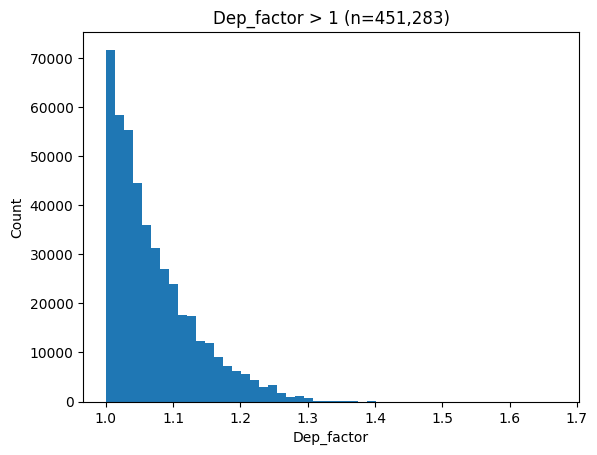

In [5]:
calc.predict_dep_factor()
diag.plot_dep_factor_distribution(calc.df)

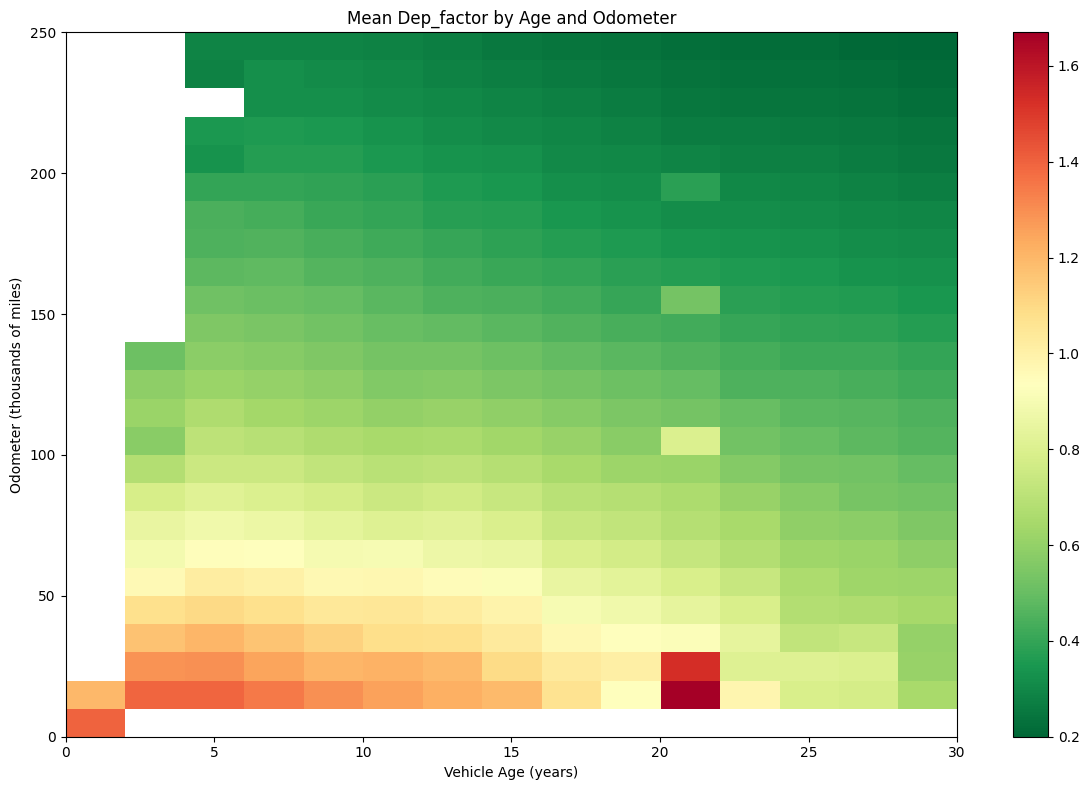

In [6]:
diag.plot_age_odometer_heatmap(calc.df)

In [7]:
suspicious = diag.find_suspicious_records(calc.df)
suspicious.head(10)

Suspicious records (age 18-24, Dep_factor > 1.2): 20


,cef_est_curr_mi_grp_imps,dml_year_imps,vc_msrp_impa,st_raw,insstate,dml_make_raw,vin,vin_date,zip,VIN,BODY_STYLE_SEGMENT_BODY_TYPE,BSST_formatted,CALC_VEH_AGE,ODOMETER_IMP_FLAG,geo_pop_density_ntile,POP_DENSITY_IMP_FLAG,Dep_factor,veh_value_dep
2275470,10000.0,2006.0,151245.0,MO,MO,FORD,1FAFP90S36Y400968,1FAFP90S36Y400968_01-01-2022,64078,1FAFP90S36Y400968,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,20.0,0,28.0,0,1.659493,250989.981086
2559559,10000.0,2005.0,151245.0,MO,MO,FORD,1FAFP90S85Y400088,1FAFP90S85Y400088_07-01-2020,64078,1FAFP90S85Y400088,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,21.0,0,28.0,0,1.605882,242881.656239
6984326,10000.0,2006.0,151245.0,AR,AR,FORD,1FAFP90S46Y401112,1FAFP90S46Y401112_01-01-2021,72116,1FAFP90S46Y401112,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,20.0,0,18.0,1,1.65645,250529.804716
12793862,10000.0,2006.0,151245.0,MA,MA,FORD,1FAFP90S76Y401394,1FAFP90S76Y401394_08-30-2019,2339,1FAFP90S76Y401394,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,20.0,0,62.0,1,1.669879,252560.912569
12884705,10000.0,2005.0,151245.0,MO,MO,FORD,1FAFP90SX5Y401176,1FAFP90SX5Y401176_07-01-2022,64078,1FAFP90SX5Y401176,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,21.0,0,28.0,0,1.605882,242881.656239
13410050,20000.0,2006.0,151245.0,MO,MO,FORD,1FAFP90S56Y400647,1FAFP90S56Y400647_07-01-2022,64078,1FAFP90S56Y400647,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,20.0,0,28.0,0,1.528659,231201.992017
14786134,10000.0,2006.0,151245.0,MO,MO,FORD,1FAFP90S26Y400072,1FAFP90S26Y400072_01-01-2022,64078,1FAFP90S26Y400072,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,20.0,0,28.0,0,1.659493,250989.981086
15927510,10000.0,2005.0,151245.0,MO,MO,FORD,1FAFP90S45Y400573,1FAFP90S45Y400573_04-01-2021,64078,1FAFP90S45Y400573,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,21.0,0,28.0,0,1.605882,242881.656239
17419339,10000.0,2005.0,151245.0,MO,MO,FORD,1FAFP90S25Y400944,1FAFP90S25Y400944_10-01-2020,64078,1FAFP90S25Y400944,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,21.0,0,28.0,0,1.605882,242881.656239
19029894,10000.0,2005.0,151245.0,MO,MO,FORD,1FAFP90S35Y401634,1FAFP90S35Y401634_01-01-2020,64078,1FAFP90S35Y401634,Prestige Sporty (Car),Prestige_Sporty_Car_GLM,21.0,0,28.0,0,1.605882,242881.656239


In [8]:
df_out = calc.export()

Exported 27,052,200 records to /Users/Mach/dev/aps/data/2026_Dmodel_data/car_with_dep_factor.parquet
